# Lab: Linear Regression
### ISLP Kapitel 3 — Python Umsetzung

---

Dieses Notebook begleitet Kapitel 3 von *An Introduction to Statistical Learning with Python* (James et al., 2023). Es ist bewusst ausführlicher gehalten als das Buch-Lab: Formeln werden erklärt, Implementierungsalternativen verglichen, und die Verbindung zwischen Theorie und Code explizit hergestellt.

**Lernziele:**
- Das statistische Modell der linearen Regression verstehen und in Python umsetzen
- Den Unterschied zwischen verschiedenen Python-Implementierungen kennen und begründen können
- Modell-Output vollständig lesen und interpretieren
- Diagnostikplots erstellen und deuten
- Erweiterungen (Interaktionen, Polynome, Dummy-Variablen) korrekt spezifizieren und interpretieren

**Datensätze:** Boston (Hauspreise), Advertising (Werbeausgaben), Carseats (Kindersitzverkäufe)

---

---
---

## 0  Setup und Paketübersicht

Bevor wir starten, ein Überblick über alle benötigten Pakete — und warum wir sie brauchen.

### Welche Pakete gibt es überhaupt für lineare Regression in Python?

Für lineare Regression existieren in Python im Wesentlichen drei relevante Pakete:

| Paket | Stärken | Schwächen | Wann nutzen? |
|---|---|---|---|
| **`statsmodels`** | Vollständige Inferenz (p-Werte, KI, F-Test, Residualdiagnostik), R-ähnlicher Output | Kein ML-Pipeline-Support | Statistik, Hypothesentests, wissenschaftliche Analyse |
| **`scikit-learn`** | ML-Pipelines, Cross-Validation, Modellvergleich, sehr einheitliche API | Keine p-Werte, keine Inferenz out-of-the-box | Vorhersage, Machine Learning |
| **`numpy.linalg`** | Volle Kontrolle, minimale Abhängigkeiten | Alles muss selbst implementiert werden | Lehre, eigene Algorithmen |

**Wir nutzen `statsmodels`**, weil wir in diesem Kurs *Inferenz* betreiben wollen: Sind Koeffizienten signifikant? Wie groß ist der F-Test? Was sind die Konfidenzintervalle? Das ist der statistische Kontext von ISLP Kapitel 3.

`scikit-learn` wäre die bessere Wahl, wenn das Ziel reine Vorhersage wäre (z.B. in Kapitel 5 bei Cross-Validation oder Kapitel 6 bei Regularisierung).

### Die ISLP-spezifischen Hilfsfunktionen

Das ISLP-Paket enthält zwei zentrale Werkzeuge, die die Notation aus dem Buch in Python übersetzen:

- **`ModelSpec` (alias `MS`):** Baut die Designmatrix auf — inklusive Intercept, Interaktionstermen, Polynomen und automatischer Dummy-Kodierung für kategoriale Variablen.
- **`summarize()`:** Gibt einen kompakten Tabellen-Output analog zur R-Funktion `summary()`.
- **`poly()`:** Erzeugt orthogonale Polynomterme (Details in Abschnitt 3).

Diese Hilfsfunktionen sind *nicht* notwendig — man kann alles auch direkt mit `statsmodels` formulieren. Sie machen den Code aber lesbarer und buchkonform.

In [1]:
# Standardbibliotheken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

# statsmodels: statistische Modellierung mit Inferenz
import statsmodels.api as sm                              # sm.OLS, sm.add_constant
import statsmodels.formula.api as smf                    # smf.ols (Formel-Interface, Alternative)
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

# ISLP: buchspezifische Hilfsfunktionen
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,               # Designmatrix-Builder
                          summarize,                     # kompakter Output
                          poly)                          # orthogonale Polynome

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

---
---

## 1  Theoretischer Hintergrund

### 1.1  Das lineare Modell — Notation

Das allgemeine multiple lineare Regressionsmodell lautet:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p + \varepsilon$$

**Bedeutung der Symbole:**
- $Y$: Zielvariable (Response, abhängige Variable) — z.B. Hauspreis `medv`
- $X_1, \ldots, X_p$: Prädiktoren (Features, unabhängige Variablen) — z.B. `lstat`, `rm`, `age`
- $\beta_0$: Intercept (Achsenabschnitt) — der mittlere Wert von $Y$ wenn alle $X_j = 0$
- $\beta_1, \ldots, \beta_p$: Regressionskoeffizienten (Steigungen) — die erwartete Änderung in $Y$ bei Erhöhung von $X_j$ um 1, *unter Kontrolle aller anderen Prädiktoren*
- $\varepsilon$: Fehlerterm — enthält alles, was das Modell nicht erklärt; Annahme: $\varepsilon \sim N(0, \sigma^2)$

### 1.2  Matrixnotation

Für $n$ Beobachtungen und $p$ Prädiktoren lässt sich das Modell kompakt in Matrixform schreiben:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

mit:

$$\mathbf{y} = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix}, \quad
\mathbf{X} = \begin{pmatrix} 1 & x_{11} & x_{12} & \cdots & x_{1p} \\ 1 & x_{21} & x_{22} & \cdots & x_{2p} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & x_{n2} & \cdots & x_{np} \end{pmatrix}, \quad
\boldsymbol{\beta} = \begin{pmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p \end{pmatrix}$$

$\mathbf{X}$ heisst **Designmatrix**. Die erste Spalte besteht aus Einsen und erzeugt den Intercept $\beta_0$. Jede weitere Spalte entspricht einem Prädiktor.

**Für den Boston-Datensatz** (`medv ~ lstat`), n = 506, p = 1:

$$\mathbf{X} = \begin{pmatrix} 1 & \texttt{lstat}_1 \\ 1 & \texttt{lstat}_2 \\ \vdots & \vdots \\ 1 & \texttt{lstat}_{506} \end{pmatrix} \in \mathbb{R}^{506 \times 2}$$

### 1.3  OLS-Schätzung

Die **Kleinste-Quadrate-Schätzung** (Ordinary Least Squares, OLS) minimiert die Residuenquadratsumme (RSS):

$$\text{RSS} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_{i1} - \cdots - \hat{\beta}_p x_{ip})^2$$

Die analytische Lösung in Matrixform:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Diese Formel setzt voraus, dass $\mathbf{X}^\top \mathbf{X}$ invertierbar ist — das ist nicht der Fall bei perfekter Kollinearität (linear abhängige Spalten).

### 1.4  Modellgüte

**RSE (Residual Standard Error):** Typische Abweichung der Vorhersagen in Einheiten von $Y$:

$$\text{RSE} = \sqrt{\frac{\text{RSS}}{n - p - 1}}$$

Der Nenner $n - p - 1$ sind die Freiheitsgrade: wir schätzen $p + 1$ Parameter ($p$ Steigungen + Intercept).

**$R^2$:** Anteil der erklärten Varianz (dimensionslos, 0 bis 1):

$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}, \quad \text{TSS} = \sum_{i=1}^n (y_i - \bar{y})^2$$

TSS ist die Gesamtvarianz in $Y$ — die Varianz, die ein Modell ohne Prädiktoren hätte (nur Intercept = Mittelwert).

**Wichtig:** $R^2$ steigt immer, wenn man mehr Prädiktoren hinzufügt — auch wenn diese keinen echten Zusammenhang mit $Y$ haben. Das korrigierte $\bar{R}^2$ bestraft dafür:

$$\bar{R}^2 = 1 - \frac{\text{RSS}/(n-p-1)}{\text{TSS}/(n-1)}$$

### 1.5  Inferenz: t-Test und F-Test

**t-Test für einzelne Koeffizienten** (H$_0$: $\beta_j = 0$):

$$t_j = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)}$$

Unter H$_0$ ist $t_j$ t-verteilt mit $n - p - 1$ Freiheitsgraden.

**F-Test** (H$_0$: $\beta_1 = \beta_2 = \cdots = \beta_p = 0$, d.h. *keiner* der Prädiktoren ist relevant):

$$F = \frac{(\text{TSS} - \text{RSS})/p}{\text{RSS}/(n-p-1)}$$

Der F-Test ist wichtig, weil bei vielen Prädiktoren einzelne t-Tests durch Zufall signifikant werden können (multiples Testen). Der F-Test kontrolliert das global.

---
---

## 2  Einfache lineare Regression: Boston-Datensatz

### 2.1  Datensatz laden und erkunden

Der Boston-Datensatz enthält Informationen über 506 Stadtteile rund um Boston. Wir wollen den **medianen Hauspreis** (`medv`, in $1.000) aus verschiedenen Prädiktoren vorhersagen.

Vollständige Variablenliste:
| Variable | Beschreibung |
|---|---|
| `crim` | Pro-Kopf-Kriminalitätsrate |
| `zn` | Anteil Wohngebiete > 25.000 qf |
| `indus` | Anteil Nicht-Einzelhandelsfläche |
| `chas` | Charles-River-Dummy (1 = grenzt an Fluss) |
| `nox` | Stickoxidkonzentration |
| `rm` | Durchschnittliche Zimmerzahl pro Haus |
| `age` | Anteil Häuser vor 1940 gebaut |
| `dis` | Gewichtete Distanz zu Beschäftigungszentren |
| `rad` | Zugang zu Radialautobahnen (Index) |
| `tax` | Grundsteuersatz pro $10.000 |
| `ptratio` | Schüler-Lehrer-Verhältnis |
| `lstat` | % Bevölkerung mit niedrigem sozioökon. Status |
| `medv` | Medianer Hauspreis in 1.000 Dollar **(Zielvariable)** |

In [2]:
Boston = load_data('Boston')
print(f'Dimensionen: {Boston.shape[0]} Beobachtungen, {Boston.shape[1]} Variablen')
Boston.head()

Dimensionen: 506 Beobachtungen, 13 Variablen


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
Boston.describe().round(2)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,37.97,50.00


### Modellierung: Einfache lineare Regression
Wir beginnen mit einer einfachen linearen Regression, um den Zusammenhang zwischen dem sozioökonomischen Status der Bevölkerung (`lstat`) und dem Hauspreis (`medv`) zu untersuchen.

**Modellgleichung:**
$$medv = \beta_0 + \beta_1 \cdot lstat + \epsilon$$

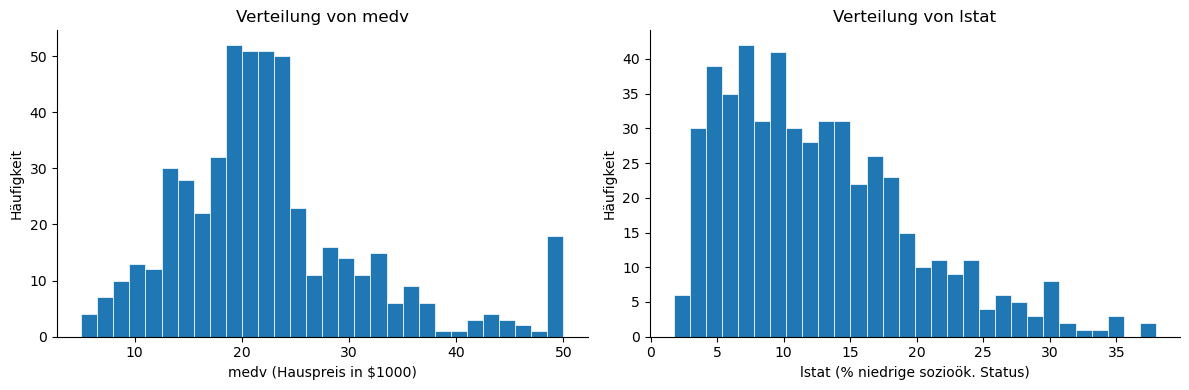

In [4]:
# Verteilung der Zielvariable
fig, axes = subplots(1, 2, figsize=(12, 4))

axes[0].hist(Boston['medv'], bins=30, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('medv (Hauspreis in $1000)')
axes[0].set_ylabel('Häufigkeit')
axes[0].set_title('Verteilung von medv')

axes[1].hist(Boston['lstat'], bins=30, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('lstat (% niedrige sozioök. Status)')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title('Verteilung von lstat')

plt.tight_layout()

### 2.2  Die Designmatrix — von Daten zu Matrixnotation

Bevor wir das Modell fitten, müssen wir die Designmatrix $\mathbf{X}$ aufbauen. Es gibt mehrere Wege:

**Weg 1: `ModelSpec` (ISLP) — buchkonform, empfohlen für diesen Kurs**

In [5]:
# ModelSpec definiert die Modellstruktur
# fit() lernt die Parameterisierung (z.B. Mittelwerte für Zentrierung, Levels für Dummies)
# transform() wendet sie auf die Daten an
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)

# Kurzform: fit_transform() kombiniert beide Schritte
X = MS(['lstat']).fit_transform(Boston)

print('Designmatrix X (erste 5 Zeilen):')
print(X.head())
print(f'\nDimension: {X.shape}  — {X.shape[0]} Beobachtungen, {X.shape[1]} Spalten (Intercept + lstat)')

Designmatrix X (erste 5 Zeilen):
   intercept  lstat
0        1.0   4.98
1        1.0   9.14
2        1.0   4.03
3        1.0   2.94
4        1.0   5.33

Dimension: (506, 2)  — 506 Beobachtungen, 2 Spalten (Intercept + lstat)


**Weg 2: `sm.add_constant()` — direkter statsmodels-Ansatz ohne ISLP**

In [6]:
X_alt1 = sm.add_constant(Boston['lstat'])
print('Alternative 1 — sm.add_constant():')
print(X_alt1.head())

Alternative 1 — sm.add_constant():
   const  lstat
0    1.0   4.98
1    1.0   9.14
2    1.0   4.03
3    1.0   2.94
4    1.0   5.33


**Weg 3: Formel-Interface mit `smf.ols()` — R-ähnliche Syntax**

In [7]:
# smf.ols akzeptiert R-style Formeln als Strings
# Das Intercept ist implizit enthalten; '-1' würde es entfernen
results_formula = smf.ols('medv ~ lstat', data=Boston).fit()
print('Alternative 2 — smf.ols (Formel-Interface):')
print(results_formula.params)
print('\nDieses Interface ist praktisch für interaktive Analyse, aber weniger')
print('flexibel für programmatische Modellspezifikation mit vielen Termen.')

Alternative 2 — smf.ols (Formel-Interface):
Intercept    34.553841
lstat        -0.950049
dtype: float64

Dieses Interface ist praktisch für interaktive Analyse, aber weniger
flexibel für programmatische Modellspezifikation mit vielen Termen.


**Weg 4: Reine numpy-Implementierung — zeigt was OLS wirklich rechnet**

In [8]:
# Die analytische OLS-Formel: beta_hat = (X'X)^{-1} X'y
X_np = np.column_stack([np.ones(len(Boston)), Boston['lstat'].values])
y_np = Boston['medv'].values

beta_hat = np.linalg.solve(X_np.T @ X_np, X_np.T @ y_np)
print(f'OLS direkt via numpy:  beta_0 = {beta_hat[0]:.4f},  beta_1 = {beta_hat[1]:.4f}')
print('(Identisch mit statsmodels — gleiche Mathematik, nur mehr Handarbeit)')

OLS direkt via numpy:  beta_0 = 34.5538,  beta_1 = -0.9500
(Identisch mit statsmodels — gleiche Mathematik, nur mehr Handarbeit)


### 2.3  Modell fitten und Output lesen

Wir nutzen im Folgenden den `MS`-Weg, weil er am besten zu den späteren Erweiterungen (Interaktionen, Polynome) passt.

In [9]:
X = MS(['lstat']).fit_transform(Boston)
y = Boston['medv']

model = sm.OLS(y, X)       # definiert das Modell (noch kein Fitting)
results = model.fit()       # schätzt die Koeffizienten via OLS

# Kompakter Output (ISLP-Hilfsfunktion)
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


**Was bedeutet dieser Output im Detail?**

| Spalte | Bedeutung |
|---|---|
| `coef` | Geschätzter Koeffizient $\hat{\beta}_j$ |
| `std err` | Standardfehler $\text{SE}(\hat{\beta}_j)$ — Unsicherheit der Schätzung |
| `t` | t-Statistik: $\hat{\beta}_j / \text{SE}(\hat{\beta}_j)$ |
| `P>\|t\|` | p-Wert für den t-Test (H$_0$: $\beta_j = 0$) |

**Für unser Modell `medv ~ lstat`:**
- $\hat{\beta}_0 \approx 34.55$: Der vorhergesagte Hauspreis beträgt ca. 34.550 Dollar, wenn `lstat = 0` (rein hypothetisch — in der Praxis gibt es keine Stadtteile mit 0% einkommensschwacher Bevölkerung).
- $\hat{\beta}_1 \approx -0.95$: Steigt der Anteil einkommensschwacher Bevölkerung um 1 Prozentpunkt, sinkt der mediane Hauspreis um ca. 950 Dollar (da `medv` in Tausend Dollar gemessen ist).
- Beide Koeffizienten sind hochsignifikant (p ≈ 0).

In [10]:
# Vollständiger statsmodels-Output mit allen Modellstatistiken
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Mon, 04 May 2026   Prob (F-statistic):           5.08e-88
Time:                        10:52:45   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.0

**Schlüsselstatistiken im vollständigen Output:**
- **R-squared ≈ 0.544:** `lstat` erklärt 54,4% der Gesamtvarianz in `medv`. Für einen einzelnen Prädiktor ist das gut, aber 45,6% der Variation bleiben unerklärt — Motivation für Multiple Regression.
- **F-statistic / Prob(F):** Testet H$_0$: $\beta_1 = 0$. Hier F ≈ 602, p ≈ 0 → der Prädiktor verbessert das Modell klar gegenüber dem Nullmodell (nur Intercept).
- **AIC / BIC:** Informationskriterien für Modellvergleich (kleinere Werte = besser, aber nur relativ vergleichbar).

**Konfidenzintervalle für die Koeffizienten:**

In [11]:
# 95%-Konfidenzintervalle
ci = results.conf_int()
ci.columns = ['2.5%', '97.5%']
print('Konfidenzintervalle (95%):')
print(ci.round(4))
print()
print(f'Interpretation lstat-KI [{ci.loc["lstat","2.5%"]:.3f}, {ci.loc["lstat","97.5%"]:.3f}]:')
print('Mit 95% Wahrscheinlichkeit liegt der wahre Koeffizient beta_1 in diesem Intervall.')
print('Da das Intervall klar negativ ist (nicht 0 enthält), ist der Effekt signifikant.')

Konfidenzintervalle (95%):
              2.5%    97.5%
intercept  33.4485  35.6592
lstat      -1.0261  -0.8740

Interpretation lstat-KI [-1.026, -0.874]:
Mit 95% Wahrscheinlichkeit liegt der wahre Koeffizient beta_1 in diesem Intervall.
Da das Intervall klar negativ ist (nicht 0 enthält), ist der Effekt signifikant.


### 2.4  Visualisierung: Streudiagramm mit Regressionslinie

Visueller Befund:
- Der Zusammenhang ist klar negativ: höhere lstat-Werte gehen mit niedrigeren Preisen einher.
- Die Streuung ist heteroskedastisch (nimmt mit lstat zu).
- Der Zusammenhang sieht eher gekrümmt aus als linear — Hinweis auf Nicht-Linearität.


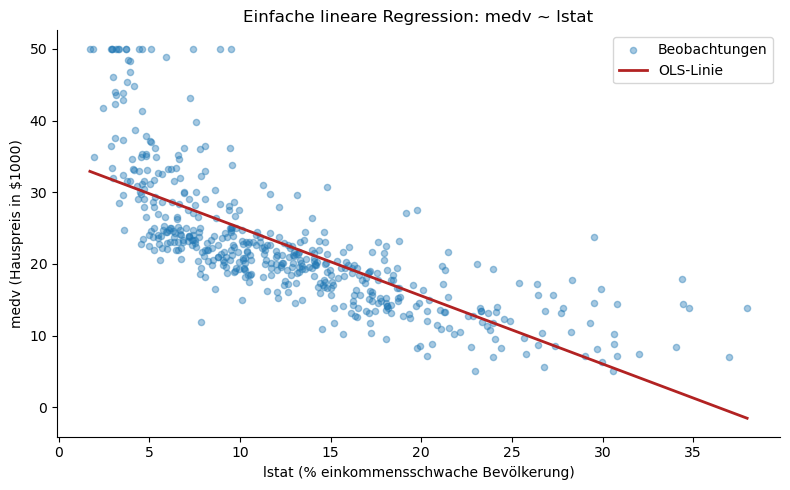

In [12]:
fig, ax = subplots(figsize=(8, 5))

# Rohdaten
ax.scatter(Boston['lstat'], y, alpha=0.4, s=20, label='Beobachtungen')

# Regressionslinie über den gesamten lstat-Bereich
lstat_range = np.linspace(Boston['lstat'].min(), Boston['lstat'].max(), 200)
X_range = MS(['lstat']).fit(Boston).transform(pd.DataFrame({'lstat': lstat_range}))
y_hat_range = results.predict(X_range)
ax.plot(lstat_range, y_hat_range, color='firebrick', lw=2, label='OLS-Linie')

ax.set_xlabel('lstat (% einkommensschwache Bevölkerung)')
ax.set_ylabel('medv (Hauspreis in $1000)')
ax.set_title('Einfache lineare Regression: medv ~ lstat')
ax.legend()
plt.tight_layout()

# Was sehen wir?
print('Visueller Befund:')
print('- Der Zusammenhang ist klar negativ: höhere lstat-Werte gehen mit niedrigeren Preisen einher.')
print('- Die Streuung ist heteroskedastisch (nimmt mit lstat zu).')
print('- Der Zusammenhang sieht eher gekrümmt aus als linear — Hinweis auf Nicht-Linearität.')

### 2.5  Vorhersagen: Konfidenz- vs. Vorhersageintervall

Es gibt zwei konzeptuell verschiedene Arten von Intervallen:

**Konfidenzintervall (CI):** Unsicherheit über den **mittleren** Hauspreis $E[Y | X = x_0]$ aller Stadtteile mit diesem `lstat`-Wert. Schmal, weil wir einen Mittelwert schätzen.

**Vorhersageintervall (PI):** Unsicherheit über den Hauspreis eines **einzelnen neuen** Stadtteils mit `lstat = x_0`. Immer breiter als CI, weil zusätzlich der irreduzibler Fehler $\varepsilon$ eingeht:

$$\text{PI breite} \approx \sqrt{\text{SE}(\hat{y})^2 + \hat{\sigma}^2}$$

In [13]:
new_data = pd.DataFrame({'lstat': [5, 10, 15, 20, 25]})
X_new = MS(['lstat']).fit(Boston).transform(new_data)

pred = results.get_prediction(X_new)
pred_df = pred.summary_frame(alpha=0.05)
pred_df.index = new_data['lstat'].values
pred_df.index.name = 'lstat'

print('Vorhersagen mit 95%-Konfidenz- und Vorhersageintervallen:')
print(pred_df[['mean', 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper']].round(2))

Vorhersagen mit 95%-Konfidenz- und Vorhersageintervallen:
        mean  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
lstat                                                                 
5      29.80          29.01          30.60         17.57         42.04
10     25.05          24.47          25.63         12.83         37.28
15     20.30          19.73          20.87          8.08         32.53
20     15.55          14.77          16.33          3.32         27.79
25     10.80           9.72          11.89         -1.46         23.06


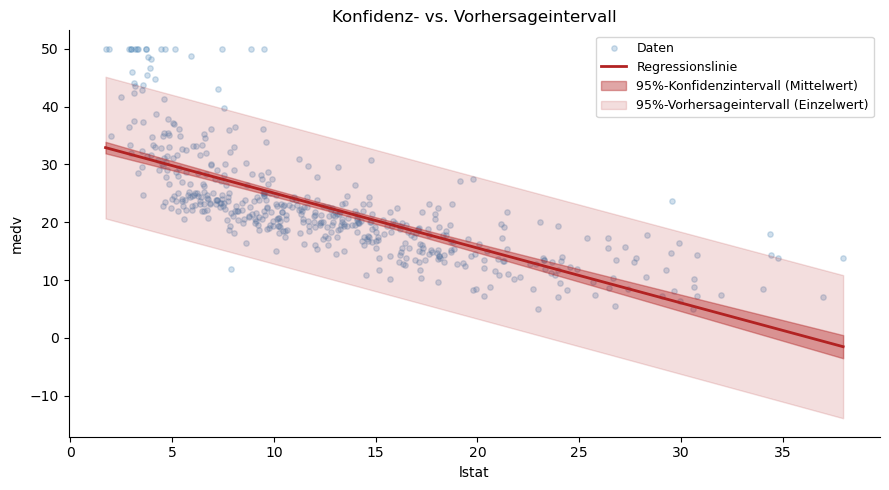

In [14]:
# Visualisierung beider Intervalltypen
lstat_plot = np.linspace(Boston['lstat'].min(), Boston['lstat'].max(), 200)
X_plot = MS(['lstat']).fit(Boston).transform(pd.DataFrame({'lstat': lstat_plot}))
pred_plot = results.get_prediction(X_plot).summary_frame(alpha=0.05)

fig, ax = subplots(figsize=(9, 5))
ax.scatter(Boston['lstat'], y, alpha=0.25, s=15, color='steelblue', label='Daten')
ax.plot(lstat_plot, pred_plot['mean'], color='firebrick', lw=2, label='Regressionslinie')
ax.fill_between(lstat_plot, pred_plot['mean_ci_lower'], pred_plot['mean_ci_upper'],
                alpha=0.4, color='firebrick', label='95%-Konfidenzintervall (Mittelwert)')
ax.fill_between(lstat_plot, pred_plot['obs_ci_lower'], pred_plot['obs_ci_upper'],
                alpha=0.15, color='firebrick', label='95%-Vorhersageintervall (Einzelwert)')
ax.set_xlabel('lstat')
ax.set_ylabel('medv')
ax.set_title('Konfidenz- vs. Vorhersageintervall')
ax.legend(fontsize=9)
plt.tight_layout()

### 2.6  Diagnose-Plots

Drei klassische Diagnose-Plots für lineare Regression:

**Plot 1: Residuals vs. Fitted Values**  
Zeigt, ob die Annahme *linearer* Zusammenhang verletzt ist. Idealfall: zufälliges Streuen um die Null-Linie ohne erkennbares Muster. Systematische Muster (U-Form, Trichter) sind Warnsignale.

**Plot 2: Q-Q-Plot der Residuen**  
Prüft die Normalverteilungsannahme der Fehler. Abweichungen an den Enden deuten auf Heavy Tails oder Schiefe hin.

**Plot 3: Leverage-Plot**  
Identifiziert einflussreiche Beobachtungen. Der **Leverage** $h_i$ misst, wie weit $x_i$ vom Zentrum des Prädiktorraums entfernt liegt:

$$h_i = \frac{1}{n} + \frac{(x_i - \bar{x})^2}{\sum_{j=1}^n (x_j - \bar{x})^2} \quad \text{(einfache Regression)}$$

Beobachtungen mit hohem Leverage **und** großem studentisierten Residuum sind besonders problematisch — sie beeinflussen die Schätzung stark und passen schlecht ins Modell.

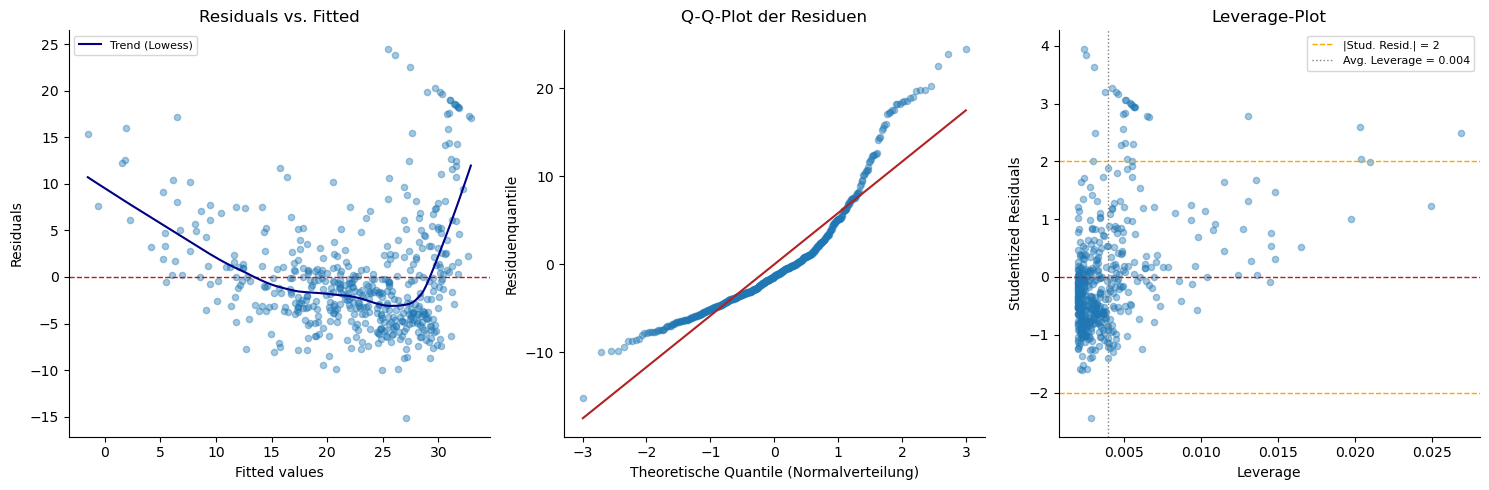

In [15]:
infl = results.get_influence()
leverage   = infl.hat_matrix_diag
stud_resid = infl.resid_studentized_internal

fig, axes = subplots(1, 3, figsize=(15, 5))

# Plot 1: Residuals vs Fitted
axes[0].scatter(results.fittedvalues, results.resid, alpha=0.4, s=20)
axes[0].axhline(0, color='firebrick', lw=1, ls='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted')

# Lowess-Smoother als visueller Trend
from statsmodels.nonparametric.smoothers_lowess import lowess
fitted_sorted = np.sort(results.fittedvalues)
smooth = lowess(results.resid[np.argsort(results.fittedvalues)],
                fitted_sorted, frac=0.4)
axes[0].plot(smooth[:, 0], smooth[:, 1], color='navy', lw=1.5, label='Trend (Lowess)')
axes[0].legend(fontsize=8)

# Plot 2: Q-Q-Plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(results.resid, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=20)
axes[1].plot([osm[0], osm[-1]], [slope*osm[0]+intercept, slope*osm[-1]+intercept],
             color='firebrick', lw=1.5)
axes[1].set_xlabel('Theoretische Quantile (Normalverteilung)')
axes[1].set_ylabel('Residuenquantile')
axes[1].set_title('Q-Q-Plot der Residuen')

# Plot 3: Leverage
axes[2].scatter(leverage, stud_resid, alpha=0.4, s=20)
axes[2].axhline(0, color='firebrick', lw=1, ls='--')
axes[2].axhline(2,  color='orange', lw=1, ls='--', label='|Stud. Resid.| = 2')
axes[2].axhline(-2, color='orange', lw=1, ls='--')
p_avg = (1 + 1) / len(Boston)   # (p+1)/n für p=1
axes[2].axvline(p_avg, color='gray', lw=1, ls=':', label=f'Avg. Leverage = {p_avg:.3f}')
axes[2].set_xlabel('Leverage')
axes[2].set_ylabel('Studentized Residuals')
axes[2].set_title('Leverage-Plot')
axes[2].legend(fontsize=8)

plt.tight_layout()

In [16]:
# Auffällige Beobachtungen identifizieren
p = 1  # Anzahl Prädiktoren
n = len(Boston)
high_leverage = leverage > 2 * (p + 1) / n   # Faustregel: > 2*(p+1)/n
large_resid   = np.abs(stud_resid) > 2

print(f'Beobachtungen mit hohem Leverage (> {2*(p+1)/n:.3f}): {high_leverage.sum()}')
print(f'Beobachtungen mit grossem studentisierten Residuum (|r| > 2): {large_resid.sum()}')
print(f'Beides (hoch einflussreich): {(high_leverage & large_resid).sum()}')

# Befund:
print()
print('Befund aus Residualplot:')
print('- U-foermiges Muster deutet auf Nicht-Linearitaet hin.')
print('- Trichterform deutet auf Heteroskedastizitaet (zunehmende Streuung).')
print('- -> Lineares Modell ist hier nicht vollstaendig angemessen.')
print('   Motivation fuer Block 3: quadratischer Term.')

Beobachtungen mit hohem Leverage (> 0.008): 34
Beobachtungen mit grossem studentisierten Residuum (|r| > 2): 32
Beides (hoch einflussreich): 4

Befund aus Residualplot:
- U-foermiges Muster deutet auf Nicht-Linearitaet hin.
- Trichterform deutet auf Heteroskedastizitaet (zunehmende Streuung).
- -> Lineares Modell ist hier nicht vollstaendig angemessen.
   Motivation fuer Block 3: quadratischer Term.


---

### 2.7  Multiple lineare Regression

**Schrittweise Erweiterung des Modells:**

Wir beginnen mit zwei Prädiktoren (`lstat` + `age`) und erweitern dann auf alle verfügbaren Variablen.

**Wichtiger Unterschied zur SLR:** Im MLR-Modell ist jeder Koeffizient ein *partieller Effekt* — die erwartete Änderung in $Y$ bei Erhöhung von $X_j$ um 1, wenn alle anderen Prädiktoren konstant gehalten werden. Das kann sich deutlich von der bivariaten Korrelation unterscheiden.

In [17]:
# Modell 1: lstat + age
X2 = MS(['lstat', 'age']).fit_transform(Boston)
results2 = sm.OLS(y, X2).fit()
summarize(results2)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [18]:
# Vergleich SLR vs MLR fuer lstat
print('Koeffizient lstat im SLR-Modell:  ', results.params['lstat'].round(4))
print('Koeffizient lstat im MLR-Modell:  ', results2.params['lstat'].round(4))
print()
print('Der Koeffizient aendert sich leicht, weil age mit lstat korreliert ist.')
print(f'Korrelation lstat-age: {Boston["lstat"].corr(Boston["age"]):.3f}')
print()
print('In der SLR absorbiert lstat einen Teil des age-Effekts (und umgekehrt).')
print('Der MLR-Koeffizient ist der sauberere, weil er age herausrechnet.')

Koeffizient lstat im SLR-Modell:   -0.95
Koeffizient lstat im MLR-Modell:   -1.0321

Der Koeffizient aendert sich leicht, weil age mit lstat korreliert ist.
Korrelation lstat-age: 0.602

In der SLR absorbiert lstat einen Teil des age-Effekts (und umgekehrt).
Der MLR-Koeffizient ist der sauberere, weil er age herausrechnet.


In [19]:
# Modell 2: alle Praediktoren
terms = Boston.columns.drop('medv')
X_all = MS(terms).fit_transform(Boston)
results_all = sm.OLS(y, X_all).fit()
summarize(results_all)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [20]:
# Vergleich der Modellguete
print(f'{"Modell":<30} {"R2":>6} {"Adj-R2":>8} {"RSE":>7} {"AIC":>10}')
print('-' * 65)
for name, res in [('SLR: medv ~ lstat',          results),
                  ('MLR: medv ~ lstat + age',     results2),
                  ('MLR: medv ~ alle',            results_all)]:
    print(f'{name:<30} {res.rsquared:>6.3f} {res.rsquared_adj:>8.3f} '
          f'{res.mse_resid**0.5:>7.3f} {res.aic:>10.1f}')

Modell                             R2   Adj-R2     RSE        AIC
-----------------------------------------------------------------
SLR: medv ~ lstat               0.544    0.543   6.216     3287.0
MLR: medv ~ lstat + age         0.551    0.549   6.173     3281.0
MLR: medv ~ alle                0.734    0.728   4.798     3035.8


In [21]:
# Welche Praediktoren sind im Vollmodell signifikant?
sig = summarize(results_all)
print('Signifikante Praediktoren (p < 0.05):')
print(sig[sig['P>|t|'] < 0.05])
print()
print('NICHT signifikant (p >= 0.05):')
print(sig[sig['P>|t|'] >= 0.05])

Signifikante Praediktoren (p < 0.05):
              coef  std err       t  P>|t|
intercept  41.6173    4.936   8.431  0.000
crim       -0.1214    0.033  -3.678  0.000
zn          0.0470    0.014   3.384  0.001
chas        2.8400    0.870   3.264  0.001
nox       -18.7580    3.851  -4.870  0.000
rm          3.6581    0.420   8.705  0.000
dis        -1.4908    0.202  -7.394  0.000
rad         0.2894    0.067   4.325  0.000
tax        -0.0127    0.004  -3.337  0.001
ptratio    -0.9375    0.132  -7.091  0.000
lstat      -0.5520    0.051 -10.897  0.000

NICHT signifikant (p >= 0.05):
         coef  std err      t  P>|t|
indus  0.0135    0.062  0.217  0.829
age    0.0036    0.013  0.271  0.787


In [22]:
# Bonus: Modell ohne age (war im 2-Praediktor-Modell signifikant, im Vollmodell nicht)
X_no_age = MS(Boston.columns.drop(['medv', 'age'])).fit_transform(Boston)
results_no_age = sm.OLS(y, X_no_age).fit()

print(f'R2 mit age:    {results_all.rsquared:.5f}')
print(f'R2 ohne age:   {results_no_age.rsquared:.5f}')
print(f'Verlust:       {results_all.rsquared - results_no_age.rsquared:.5f}')
print()
print('age ist im Vollmodell redundant — seine Information steckt bereits in anderen')
print('Praediktoren (insb. lstat). Ein klassisches Konfundierungsbeispiel.')

R2 mit age:    0.73431
R2 ohne age:   0.73427
Verlust:       0.00004

age ist im Vollmodell redundant — seine Information steckt bereits in anderen
Praediktoren (insb. lstat). Ein klassisches Konfundierungsbeispiel.


---
---

## Pause 

---
---

## 3  Erweiterungen des linearen Modells

Das lineare Modell macht zwei starke Annahmen:

1. **Additivität:** Der Effekt von $X_j$ auf $Y$ ist unabhängig von den Werten der anderen Prädiktoren.
2. **Linearität:** Der Effekt einer Einheitsänderung in $X_j$ ist überall konstant.

Beide Annahmen sind in der Praxis oft verletzt. Wir behandeln drei Erweiterungen:

- **Interaktionsterme:** Heben die Additivitätsannahme auf (Abschnitt 3.1)
- **Polynomterme:** Heben die Linearitätsannahme auf (Abschnitt 3.2)
- **Dummy-Variablen für kategoriale Prädiktoren:** Ermöglichen kategoriale Prädiktoren (Abschnitt 3.3)

---

### 3.1  Interaktionsterme

**Wann brauchen wir Interaktionen?**

Immer wenn der Effekt eines Prädiktors $X_1$ auf $Y$ von der Höhe eines anderen Prädiktors $X_2$ abhängt — und umgekehrt.

**Beispiel:** TV-Werbung ist effektiver, wenn gleichzeitig auch Radio-Werbung geschaltet wird. Die beiden Medien *verstärken* sich gegenseitig (Synergieeffekt).

Das additive Modell ohne Interaktion:
$$Y = \beta_0 + \beta_1 \cdot \text{TV} + \beta_2 \cdot \text{radio} + \varepsilon$$

Hier gilt: Eine Einheit mehr TV-Budget erhöht den Umsatz immer um $\beta_1$ — egal wie viel in Radio investiert wird.

Das Modell **mit** Interaktionsterm $X_1 \cdot X_2$:
$$Y = \beta_0 + \beta_1 \cdot \text{TV} + \beta_2 \cdot \text{radio} + \beta_3 \cdot (\text{TV} \times \text{radio}) + \varepsilon$$

Umgeschrieben:
$$Y = \beta_0 + (\beta_1 + \beta_3 \cdot \text{radio}) \cdot \text{TV} + \beta_2 \cdot \text{radio} + \varepsilon$$

Jetzt ist der effektive TV-Koeffizient $\tilde{\beta}_1 = \beta_1 + \beta_3 \cdot \text{radio}$ — er hängt vom Radio-Budget ab. Das ist der Synergieeffekt.

**Was ist beim Interaktionsterm zu beachten?**

- **Hierarchieprinzip:** Wenn ein Interaktionsterm im Modell ist, sollten auch die Haupteffekte der beteiligten Variablen enthalten sein — auch wenn diese nicht signifikant sind. Ein Modell mit $X_1 X_2$ aber ohne $X_1$ ist schwer interpretierbar.
- **Skalierung:** Interaktionsterme können numerisch sehr groß werden, wenn die Prädiktoren große Wertebereiche haben. In solchen Fällen hilft Zentrierung (Subtraktion des Mittelwerts).

In [26]:
Advertising = load_data('Advertising')
print(Advertising.shape)
Advertising.describe().round(2)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\hubersi\\.conda\\envs\\stamo24\\Lib\\site-packages\\ISLP\\data\\Advertising.csv'

In [ ]:
Advertising = pd.read_csv("Advertising.csv", index_col=0)
print(Advertising.shape)
Advertising.head()

In [ ]:
Advertising.describe().round(2)

In [ ]:
# Visualisierung: Hinweis auf Interaktionseffekt
fig, axes = subplots(1, 2, figsize=(12, 5))

# Linkspanel: Streuung bei verschiedenen Radio-Niveaus
radio_low  = Advertising['radio'] < Advertising['radio'].quantile(0.33)
radio_high = Advertising['radio'] > Advertising['radio'].quantile(0.67)

axes[0].scatter(Advertising.loc[radio_low, 'TV'],
                Advertising.loc[radio_low, 'sales'],
                alpha=0.6, s=25, label='Radio: niedrig (unterstes Drittel)', color='steelblue')
axes[0].scatter(Advertising.loc[radio_high, 'TV'],
                Advertising.loc[radio_high, 'sales'],
                alpha=0.6, s=25, label='Radio: hoch (oberstes Drittel)', color='firebrick')
axes[0].set_xlabel('TV-Budget')
axes[0].set_ylabel('Sales')
axes[0].set_title('Sales vs. TV — aufgeteilt nach Radio-Budget')
axes[0].legend(fontsize=8)

# Rechtspanel: 3D-Effekt als Heatmap
tv_vals = np.linspace(Advertising['TV'].min(), Advertising['TV'].max(), 50)
radio_vals = np.linspace(Advertising['radio'].min(), Advertising['radio'].max(), 50)
TV_grid, Radio_grid = np.meshgrid(tv_vals, radio_vals)

# Vorhersagen des additiven Modells (ohne Interaktion)
X_add = MS(['TV', 'radio']).fit_transform(Advertising)
res_add = sm.OLS(Advertising['sales'], X_add).fit()
pred_add = (res_add.params['intercept'] +
            res_add.params['TV'] * TV_grid +
            res_add.params['radio'] * Radio_grid)

im = axes[1].contourf(TV_grid, Radio_grid, pred_add, levels=15, cmap='RdYlGn')
plt.colorbar(im, ax=axes[1], label='Predicted Sales')
axes[1].set_xlabel('TV')
axes[1].set_ylabel('Radio')
axes[1].set_title('Vorhersage additives Modell (ohne Interaktion)')
plt.tight_layout()

In [ ]:
# Additives Modell (ohne Interaktion)
X_add = MS(['TV', 'radio']).fit_transform(Advertising)
y_adv = Advertising['sales']
results_add = sm.OLS(y_adv, X_add).fit()

print('Additives Modell (ohne Interaktion):')
summarize(results_add)

In [ ]:
# Modell MIT Interaktionsterm
# In ModelSpec: Interaktion als Tupel ('TV', 'radio')
# Das Hierarchieprinzip ist erfuellt: TV und radio sind als Haupteffekte enthalten
X_int = MS(['TV', 'radio', ('TV', 'radio')]).fit_transform(Advertising)
results_int = sm.OLS(y_adv, X_int).fit()

print('Modell mit Interaktionsterm TV x radio:')
summarize(results_int)

In [ ]:
# Vergleich additiv vs. interaktiv
print(f'{"Modell":<35} {"R2":>6} {"RSE":>7}')
print('-' * 52)
print(f'{"Additiv (TV + radio)":<35} {results_add.rsquared:>6.4f} {results_add.mse_resid**0.5:>7.4f}')
print(f'{"Interaktiv (TV + radio + TVxradio)":<35} {results_int.rsquared:>6.4f} {results_int.mse_resid**0.5:>7.4f}')
print()
print(f'R2-Gewinn durch Interaktionsterm: {results_int.rsquared - results_add.rsquared:.4f}')
print()
print('Interpretation beta_3 (TV:radio) = 0.0011:')
print('Eine Erhoehung des Radio-Budgets um 1 Einheit erhoeht die Effektivitaet von TV')
print('um 0.0011 zusaetzliche Sales-Einheiten pro TV-Budgeteinheit — und umgekehrt.')
print()
print('Effektiver TV-Koeffizient bei radio = 20:')
beta1 = results_int.params['TV']
beta3 = results_int.params['TV:radio']
print(f'  beta_TV_eff = {beta1:.4f} + {beta3:.4f} * 20 = {beta1 + beta3*20:.4f}')
print('Effektiver TV-Koeffizient bei radio = 50:')
print(f'  beta_TV_eff = {beta1:.4f} + {beta3:.4f} * 50 = {beta1 + beta3*50:.4f}')

In [ ]:
# Alternativ via smf (Formel-Interface): Interaktion mit * oder :
# TV * radio = TV + radio + TV:radio (Haupteffekte + Interaktion)
# TV : radio = nur der Interaktionsterm (ohne Haupteffekte -- nicht empfohlen)
results_smf_int = smf.ols('sales ~ TV * radio', data=Advertising).fit()
print('Identische Koeffizienten via smf.ols:')
print(results_smf_int.params.round(4))

---

### 3.2  Polynomterme und Nicht-Linearität

**Motivation:** Der Residualplot aus Abschnitt 2.6 zeigte ein U-förmiges Muster — ein klares Signal, dass der lineare Zusammenhang zwischen `lstat` und `medv` nicht angemessen ist. Wir erweitern das Modell um einen quadratischen Term:

$$\text{medv} = \beta_0 + \beta_1 \cdot \text{lstat} + \beta_2 \cdot \text{lstat}^2 + \varepsilon$$

**Wie viele Polynomterme brauchen wir?**

In der Praxis ist die Antwort fast immer: **maximal Grad 2 oder 3**. Höhere Grade
- überfitten leicht (besonders bei kleinem Datensatz)
- werden numerisch instabil
- sind schwer interpretierbar

**Vorgehen zur Entscheidung:**
1. Residualplot des linearen Modells anschauen: Gibt es ein systematisches Muster?
2. Quadratischen Term hinzufügen, ANOVA-Test (Modellvergleich) durchführen
3. Falls immer noch Muster: kubischen Term, nochmals testen
4. Ab Grad 4: fast immer besser, nichtparametrische Methoden (Splines, GAMs) zu nutzen

**`poly()` — orthogonale Polynome:**

`poly('lstat', degree=2)` erzeugt *orthogonale* Polynomterme, d.h. die erzeugten Spalten sind unkorreliert. Das hat numerische Vorteile:
- Stabilere Koeffizientenschätzung bei hohem Polynomgrad
- Die t-Tests für einzelne Terme sind unabhängig voneinander interpretierbar

Mit `raw=True` würde man stattdessen einfach `lstat` und `lstat²` als Spalten erhalten — die Fitted Values sind identisch, aber die Koeffizienten ändern sich.

**Wichtig:** `poly()` ist ein Modellierungswerkzeug, kein inhaltliches Statement. Das zugrundeliegende Modell ist immer noch linear in den Parametern — nur die *Prädiktoren* sind polynomisch transformiert.

In [ ]:
# Visualisierung: Warum ist Nicht-Linearitaet plausibel?
fig, axes = subplots(1, 2, figsize=(13, 5))

# Links: Streudiagramm lstat vs medv
axes[0].scatter(Boston['lstat'], y, alpha=0.4, s=20)
# Lowess-Smoother zeigt den nichtparametrischen Trend
from statsmodels.nonparametric.smoothers_lowess import lowess
lstat_vals = Boston['lstat'].values
smooth = lowess(y.values, lstat_vals, frac=0.3)
axes[0].plot(smooth[:, 0], smooth[:, 1], color='firebrick', lw=2, label='Lowess-Trend')
# Lineare Regressionslinie
lstat_range = np.linspace(lstat_vals.min(), lstat_vals.max(), 200)
X_range = MS(['lstat']).fit(Boston).transform(pd.DataFrame({'lstat': lstat_range}))
axes[0].plot(lstat_range, results.predict(X_range), color='steelblue', lw=2,
             ls='--', label='Lineares Modell')
axes[0].set_xlabel('lstat')
axes[0].set_ylabel('medv')
axes[0].set_title('Streudiagramm mit Lowess-Trend')
axes[0].legend(fontsize=8)

# Rechts: Residualplot des linearen Modells
axes[1].scatter(results.fittedvalues, results.resid, alpha=0.4, s=20)
axes[1].axhline(0, color='firebrick', lw=1, ls='--')
smooth2 = lowess(results.resid, results.fittedvalues, frac=0.4)
axes[1].plot(smooth2[:, 0], smooth2[:, 1], color='navy', lw=2, label='Lowess-Trend')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs. Fitted — lineares Modell')
axes[1].legend(fontsize=8)
plt.tight_layout()

print('Links: Der Lowess-Smoother (nichtparametrisch) zeigt einen gekruemmten Zusammenhang.')
print('Rechts: Das U-Muster in den Residuen bestaetigt die Nicht-Linearitaet.')

In [ ]:
# Lineares Modell (Referenz): medv ~ lstat + age
X_lin = MS(['lstat', 'age']).fit_transform(Boston)
results_lin = sm.OLS(y, X_lin).fit()

# Quadratisches Modell: medv ~ poly(lstat, 2) + age
X_quad = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
results_quad = sm.OLS(y, X_quad).fit()

# Kubisches Modell: medv ~ poly(lstat, 3) + age
X_cub = MS([poly('lstat', degree=3), 'age']).fit_transform(Boston)
results_cub = sm.OLS(y, X_cub).fit()

print('Lineares Modell:')
summarize(results_lin)

In [ ]:
print('Quadratisches Modell:')
summarize(results_quad)

In [ ]:
# Modellvergleich via ANOVA
# anova_lm benoetigt geschachtelte Modelle (jedes ist Teilmodell des naechsten)
print('ANOVA-Vergleich: linear vs. quadratisch vs. kubisch')
print()
print(anova_lm(results_lin, results_quad, results_cub))
print()
print('Interpretation:')
print('- Zeile 1 (lin->quad): F-Test ob quad. Term signifikant ist.')
print('  Kleines Pr(>F) -> quadratischer Term ist notwendig.')
print('- Zeile 2 (quad->cub): F-Test ob kub. Term zusaetzlich noetig.')
print('  Wenn Pr(>F) gross -> kubischer Term bringt nichts Neues.')

In [ ]:
# R2-Vergleich aller Polynomgrade
print(f'{"Modell":<35} {"R2":>6} {"Adj-R2":>8} {"AIC":>10}')
print('-' * 63)
for name, res in [('Linear (lstat + age)',      results_lin),
                  ('Quadratisch (poly=2 + age)', results_quad),
                  ('Kubisch (poly=3 + age)',     results_cub)]:
    print(f'{name:<35} {res.rsquared:>6.4f} {res.rsquared_adj:>8.4f} {res.aic:>10.1f}')

In [ ]:
# Visueller Vergleich der Fits
lstat_range = np.linspace(Boston['lstat'].min(), Boston['lstat'].max(), 300)
age_mean = Boston['age'].mean()  # age auf Mittelwert halten

df_range = pd.DataFrame({'lstat': lstat_range, 'age': age_mean})
X_r_lin  = MS(['lstat', 'age']).fit(Boston).transform(df_range)
X_r_quad = MS([poly('lstat', degree=2), 'age']).fit(Boston).transform(df_range)
X_r_cub  = MS([poly('lstat', degree=3), 'age']).fit(Boston).transform(df_range)

fig, ax = subplots(figsize=(9, 5))
ax.scatter(Boston['lstat'], y, alpha=0.25, s=15, color='gray', label='Daten')
ax.plot(lstat_range, results_lin.predict(X_r_lin),
        color='steelblue', lw=2, ls='--', label='Linear')
ax.plot(lstat_range, results_quad.predict(X_r_quad),
        color='firebrick', lw=2, label='Quadratisch')
ax.plot(lstat_range, results_cub.predict(X_r_cub),
        color='darkgreen', lw=2, ls=':', label='Kubisch')
ax.set_xlabel('lstat (age auf Mittelwert fixiert)')
ax.set_ylabel('medv (vorhergesagt)')
ax.set_title('Vergleich: linear vs. quadratisch vs. kubisch')
ax.legend()
plt.tight_layout()

In [ ]:
# Residualplots vergleichen: verschwindet das Muster?
fig, axes = subplots(1, 2, figsize=(13, 5))

for ax, res, title in zip(axes,
                           [results_lin, results_quad],
                           ['Lineares Modell', 'Quadratisches Modell']):
    ax.scatter(res.fittedvalues, res.resid, alpha=0.4, s=20)
    ax.axhline(0, color='firebrick', lw=1, ls='--')
    smooth = lowess(res.resid, res.fittedvalues, frac=0.4)
    ax.plot(smooth[:, 0], smooth[:, 1], color='navy', lw=1.5, label='Lowess')
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'Residuals vs. Fitted — {title}')
    ax.legend(fontsize=8)
plt.tight_layout()

---

### 3.3  Kollinearität und Variance Inflation Factor (VIF)

**Was ist Kollinearität?**

Kollinearität liegt vor, wenn zwei oder mehr Prädiktoren stark miteinander korrelieren. Das ist problematisch, weil das Modell dann die individuellen Effekte der Prädiktoren schwer voneinander trennen kann:

- Die Standardfehler der Koeffizienten steigen stark an (die Schätzungen werden instabil)
- t-Statistiken sinken → Prädiktoren erscheinen nicht signifikant, obwohl sie es sind
- Ein kleiner Datenfehler kann die Koeffizientenschätzungen stark verändern

**Variance Inflation Factor (VIF):**

Der VIF für Prädiktor $X_j$ ist:

$$\text{VIF}(\hat{\beta}_j) = \frac{1}{1 - R^2_{X_j | X_{-j}}}$$

wobei $R^2_{X_j | X_{-j}}$ das $R^2$ einer Regression von $X_j$ auf alle anderen Prädiktoren ist. Je mehr $X_j$ durch die anderen Prädiktoren erklärbar ist, desto größer der VIF.

- **VIF = 1:** Keine Kollinearität
- **VIF = 5:** Moderat, noch akzeptabel
- **VIF > 10:** Problematisch

**Was tun bei hohem VIF?**
1. Einen der kollinearen Prädiktoren entfernen (der inhaltlich weniger interessante)
2. Beide Prädiktoren zu einer neuen Variable kombinieren (z.B. Durchschnitt)
3. Regularisierung (Ridge Regression — ISLP Kapitel 6)

In [ ]:
# VIF fuer alle Praediktoren im Vollmodell
vals = [VIF(X_all.values, i) for i in range(1, X_all.shape[1])]
vif_df = pd.DataFrame({'VIF': vals}, index=X_all.columns[1:])
vif_df = vif_df.sort_values('VIF', ascending=False)

print('VIF-Werte im Vollmodell (Boston):')
print(vif_df.round(2))
print()
print('Faustregeln: VIF > 5 = moderat, VIF > 10 = problematisch')

In [ ]:
# Korrelationsmatrix der Praediktoren
corr = Boston.drop(columns='medv').corr()

fig, ax = subplots(figsize=(10, 8))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
ax.set_title('Korrelationsmatrix der Praediktoren (Boston)')

# Korrelationswerte eintragen
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)
plt.tight_layout()

In [ ]:
# Auffaelligste Kollinearitaeten
print('Stark korrelierte Praeadiktorpaare (|r| > 0.7):')
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {corr.columns[i]:10s} x {corr.columns[j]:10s}:  r = {r:.3f}')

---

### 3.4  Kategoriale Prädiktoren und Dummy-Variablen

**Das Problem:** Kategoriale Variablen wie `ShelveLoc` (Bad / Medium / Good) haben keine natürliche numerische Repräsentation. Wir können nicht einfach 1, 2, 3 kodieren — das würde eine Ordnung und gleiche Abstände implizieren, die nicht existieren.

**Lösung: Dummy-Variablen (One-Hot-Encoding)**

Für eine Variable mit $k$ Kategorien erstellen wir $k - 1$ Binärvariablen. Die weggelassene Kategorie heisst **Referenzkategorie** (Baseline). Alle Koeffizienten werden *relativ zur Referenz* interpretiert.

Für `ShelveLoc` mit Kategorien {Bad, Medium, Good}:

$$D_\text{Medium} = \begin{cases} 1 & \text{wenn ShelveLoc = Medium} \\ 0 & \text{sonst} \end{cases}, \quad D_\text{Good} = \begin{cases} 1 & \text{wenn ShelveLoc = Good} \\ 0 & \text{sonst} \end{cases}$$

Das Modell:
$$Y = \beta_0 + \beta_1 D_\text{Medium} + \beta_2 D_\text{Good} + \ldots + \varepsilon$$

Interpretation:
- $\beta_0$: Mittlere Sales bei Bad (Referenz) — wenn alle anderen Prädiktoren = 0
- $\beta_1$: Zusätzliche Sales bei Medium *gegenüber* Bad
- $\beta_2$: Zusätzliche Sales bei Good *gegenüber* Bad

**Warum $k-1$ und nicht $k$ Dummies?**

Mit $k$ Dummies wäre die Designmatrix nicht vollrangig (die $k$ Dummy-Spalten summieren zu 1, was der Intercept-Spalte entspricht) → Perfekte Kollinearität → $\mathbf{X}^\top\mathbf{X}$ nicht invertierbar. Man spricht von der *Dummy-Falle* (Dummy Variable Trap).

**Verschiedene Kodierungsschemas:**

| Schema | Beschreibung | Koeffizienten-Interpretation |
|---|---|---|
| **Treatment (default)** | Referenzkategorie = 0, alle anderen = 1 | Effekt relativ zur Referenz |
| **Deviationskontraste** | Kodierung −1 / +1 | Effekt relativ zum Gesamtmittel |
| **Effektkontraste** | Variante von Deviation Coding | Gebräuchlich in Psychologie/Sozialwiss. |

`ModelSpec` nutzt standardmäßig Treatment-Coding (häufigste Wahl in Statistik und Machine Learning).

In [ ]:
Carseats = load_data('Carseats')
print(f'Dimensionen: {Carseats.shape}')
print()
print('Variablentypen:')
print(Carseats.dtypes)
print()
print('Kategoriale Variablen:')
for col in Carseats.select_dtypes(include='object').columns:
    print(f'  {col}: {Carseats[col].unique()}')

In [ ]:
# Wie sieht die automatisch generierte Designmatrix aus?
# ModelSpec erstellt Dummies automatisch fuer Spalten vom Typ 'object' oder 'category'
X_demo = MS(['ShelveLoc', 'Urban', 'US']).fit_transform(Carseats)
print('Designmatrix mit Dummy-Variablen (erste 10 Zeilen):')
print(X_demo.head(10))
print()
print('Automatisch erstellte Spalten:')
print(X_demo.columns.tolist())
print()
print('Referenzkategorien (weggelassene Dummies):')
print('  ShelveLoc: Bad  (weil Bad alphabetisch zuerst kommt)')
print('  Urban:     No')
print('  US:        No')

In [ ]:
# Vollstaendiges Carseats-Modell mit Interaktionen
y_cs = Carseats['Sales']
allvars = list(Carseats.columns.drop('Sales'))
final  = allvars + [('Income', 'Advertising'), ('Price', 'Age')]
X_cs   = MS(final).fit_transform(Carseats)
results_cs = sm.OLS(y_cs, X_cs).fit()
summarize(results_cs)

In [ ]:
# Visualisierung: Effekt von ShelveLoc
fig, axes = subplots(1, 2, figsize=(12, 5))

# Boxplot Sales nach ShelveLoc
for i, loc in enumerate(['Bad', 'Medium', 'Good']):
    data = Carseats.loc[Carseats['ShelveLoc'] == loc, 'Sales']
    axes[0].boxplot(data, positions=[i], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=['#d9534f','#f0ad4e','#5cb85c'][i], alpha=0.7))
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Bad', 'Medium', 'Good'])
axes[0].set_xlabel('ShelveLoc')
axes[0].set_ylabel('Sales')
axes[0].set_title('Verteilung Sales nach Regalposition')

# Mittlere Sales + Modellvorhersage nach ShelveLoc
raw_means = Carseats.groupby('ShelveLoc')['Sales'].mean()
# Modellvorhersage: alle anderen Variablen auf Mittelwert halten
other_means = {col: Carseats[col].mean() if Carseats[col].dtype != 'object' else Carseats[col].mode()[0]
               for col in Carseats.columns if col != 'Sales'}
pred_data = []
for loc in ['Bad', 'Medium', 'Good']:
    row = dict(other_means)
    row['ShelveLoc'] = loc
    pred_data.append(row)
pred_df = pd.DataFrame(pred_data)
X_pred = MS(final).fit(Carseats).transform(pred_df)
pred_means = results_cs.predict(X_pred)

x = np.arange(3)
width = 0.35
axes[1].bar(x - width/2, raw_means[['Bad','Medium','Good']].values,
            width, label='Empirische Mittelwerte', alpha=0.8, color=['#d9534f','#f0ad4e','#5cb85c'])
axes[1].bar(x + width/2, pred_means.values, width,
            label='Modellvorhersage', alpha=0.6, color=['#d9534f','#f0ad4e','#5cb85c'],
            edgecolor='black', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Bad', 'Medium', 'Good'])
axes[1].set_xlabel('ShelveLoc')
axes[1].set_ylabel('Sales')
axes[1].set_title('Empirisch vs. Modellvorhersage')
axes[1].legend(fontsize=8)
plt.tight_layout()

In [ ]:
# Alternative Kodierungsschemas demonstrieren
print('--- Treatment-Coding (Standard, ModelSpec-Default) ---')
print('Bad = Referenz, Medium und Good relativ zu Bad.')
print()
X_treat = MS(['ShelveLoc']).fit_transform(Carseats)
res_treat = sm.OLS(y_cs, X_treat).fit()
print(summarize(res_treat))

print()
print('--- Manuelles Deviations-Coding (-1 / +1 / 0) ---')
# Kodierung: Bad = -1, Medium = 0, Good = +1  (vereinfachtes Beispiel)
# Hier: zwei Kontrastvariablen (Bad vs. Middle, Middle vs. Good)
Carseats_dev = Carseats.copy()
Carseats_dev['SL_MedVsBad'] = (Carseats['ShelveLoc'] == 'Medium').astype(int) -                                (Carseats['ShelveLoc'] == 'Bad').astype(int)
Carseats_dev['SL_GoodVsMed'] = (Carseats['ShelveLoc'] == 'Good').astype(int) -                                 (Carseats['ShelveLoc'] == 'Medium').astype(int)
X_dev = MS(['SL_MedVsBad', 'SL_GoodVsMed']).fit_transform(Carseats_dev)
res_dev = sm.OLS(y_cs, X_dev).fit()
print('Koeffizienten interpretieren als Unterschiede zwischen benachbarten Gruppen.')
print(summarize(res_dev))
print()
print('Wichtig: Die Fitted Values sind identisch — nur die Interpretation der')
print('Koeffizienten aendert sich je nach Kodierungsschema.')
print(f'Max. Differenz Fitted Values: {abs(res_treat.fittedvalues - res_dev.fittedvalues).max():.10f}')

---
---

## 4  Freie Exploration

Wählt eine der folgenden Aufgaben. Schnelle Teams: beide bearbeiten.

---

### Aufgabe A — Auto-Datensatz: `mpg ~ horsepower`

*Quelle: ISLP Exercises 8 und 9 (Kap. 3.7)*

1. Ladet den `Auto`-Datensatz (`load_data('Auto')`) und verschafft euch einen Überblick.
2. Fittet eine einfache lineare Regression: `mpg ~ horsepower`. Interpretiert den Output vollständig.
3. Was ist der vorhergesagte `mpg` für `horsepower = 98`? Berechnet Konfidenz- und Vorhersageintervall.
4. Erstellt Streudiagramm mit Regressionslinie und Diagnose-Plots. Ist das Modell angemessen?
5. Fittet `mpg ~ poly(horsepower, degree=2)` und vergleicht mit ANOVA und Residualplot.
6. Bonus: Multiple Regression mit allen Prädiktoren außer `name`. Welche sind signifikant?

---

### Aufgabe B — Boston: Kriminalitätsrate vorhersagen

*Quelle: ISLP Exercise 15 (Kap. 3.7)*

1. Fittet für jeden Prädiktor eine SLR mit `crim` als Zielvariable. Welche sind signifikant?
2. Fittet ein MLR-Modell mit allen Prädiktoren. Welche sind jetzt noch signifikant?
3. Vergleichsplot: Univariate Koeffizienten (x-Achse) vs. multiple Koeffizienten (y-Achse). Ein Punkt pro Prädiktor. Was fällt auf?
4. Bonus: Für jeden Prädiktor, fittet `crim ~ X + X² + X³`. Bei welchen gibt es Hinweise auf Nicht-Linearität?

---

In [ ]:
# Euer Code hier...


---
---

## Abschluss — Zusammenfassung

### Wann welche Erweiterung?

| Situation | Erweiterung | Python |
|---|---|---|
| Zusammenhang ist gekrümmt (Residualplot) | Polynomterm | `MS([poly('x', degree=2)])` |
| Effekt von X1 hängt von X2 ab | Interaktionsterm | `MS(['x1', 'x2', ('x1', 'x2')])` |
| Kategoriale Variable als Prädiktor | Dummy-Variablen | automatisch durch `MS()` |
| Prädiktoren stark korreliert | VIF berechnen, ggf. entfernen | `VIF(X, i)` |
| Modelle vergleichen | ANOVA-F-Test | `anova_lm(res_klein, res_gross)` |

### Befehlsübersicht

| Aufgabe | Code |
|---|---|
| Designmatrix bauen | `MS(['x1', 'x2']).fit_transform(df)` |
| Modell fitten | `sm.OLS(y, X).fit()` |
| Kompakter Output | `summarize(results)` |
| Vollständiger Output | `results.summary()` |
| Konfidenzintervalle | `results.conf_int()` |
| Vorhersagen | `results.get_prediction(X_new).summary_frame()` |
| Residuals | `results.resid`, `results.fittedvalues` |
| Leverage | `results.get_influence().hat_matrix_diag` |
| Studentized Residuals | `results.get_influence().resid_studentized_internal` |
| VIF | `VIF(X.values, i)` |
| ANOVA-Modellvergleich | `anova_lm(results1, results2)` |

### Die vier zentralen Diagnosefragen

1. **Ist der Zusammenhang linear?** → Residuals vs. Fitted Plot
2. **Sind die Fehler normalverteilt?** → Q-Q-Plot
3. **Gibt es Heteroskedastizität?** → Residuals vs. Fitted (Trichterform?)
4. **Gibt es einflussreiche Beobachtungen?** → Leverage-Plot